Per un fit lineare ho:
\begin{equation}
y_\mu = f^{(1)}(x_\mu, \{\vec{\theta}\}) + \eta_\mu= \theta_0 + \theta_1x_\mu + \eta_\mu
\end{equation}

Nel caso di un polinomio generico di grado $\alpha$, contenente $\alpha+1$ parametri:
\begin{equation}
y_\mu = f^{\alpha}(x_\mu, \{\vec{\theta}\}) = \vec{X_\mu}\cdot\vec{\theta} + \eta_\mu
\end{equation}
dove $\vec{X_\mu}$ è un vettore che contiene $\alpha+1$ elementi $\vec{X_\mu} = (1, x_\mu, x_\mu^2, ..., x_\mu^\alpha)$ e $\vec{\theta}$ è il vettore dei pesi.

\begin{equation}
P(\{\vec{\theta}\}| \{x_\mu, y_\mu\}) = \frac{P(\{x_\mu, y_\mu\}|\{\vec{\theta}\})P(\{\vec{\theta}\})}{P(\{x_\mu, y_\mu\} )}
\end{equation}

Cerco i parametri $\{\vec{\theta}\}$ che massimizzano il termine a sinistra.
Dato che $\eta_\mu$ è un valore gaussiano a media $\mu=0$ e varianza $\sigma$ e i dati $\{x_\mu, y_\mu\}$ sono indipendenti tra loro, la distribuzione:

\begin{equation}
P(\{x_\mu, y_\mu\}|\{\vec{\theta}\}) = \prod_{\mu=1}^P \frac{1}{\sqrt{2\pi\sigma^2}}\exp{\left(-\frac{(y_\mu - \vec{X_\mu}\cdot\vec{\theta})^2}{2\sigma^2}\right)}
\end{equation}

Massimizzare $P(\{\vec{\theta}\}| \{x_\mu, y_\mu\})$ rispetto ai parametri significa (per la monotonia del logaritmo):

\begin{equation}
\max_{\vec{\theta}}P(\{\vec{\theta}\}| \{x_\mu, y_\mu\}) = \max_{\vec{\theta}} \log({P(\{\vec{\theta}\}| \{x_\mu, y_\mu\}})) \propto -\sum_{\mu=1}^P(y_\mu - \vec{X_\mu}\cdot\vec{\theta})^2
\end{equation}
\begin{equation}
\max_{\vec{\theta}}P(\{\vec{\theta}\}| \{x_\mu, y_\mu\}) = \min_{\vec{\theta}} \sum_{\mu=1}^P(y_\mu - \vec{X_\mu}\cdot\vec{\theta})^2 = \min_{\vec{\theta}} L(\{x_\mu, y_\mu\}, \{\vec{\theta}\})
\end{equation}
Dove $L(\{x_\mu, y_\mu\}, \{\vec{\theta}\}) = \frac{1}{2}\sum_{\mu=1}^P(y_\mu - \vec{X_\mu}\cdot\vec{\theta})^2$
Posso riscrivere $L(\{x_\mu, y_\mu\}, \{\vec{\theta}\})$ come la norma di un vettore che ha come righe i singoli $y_\mu - \vec{X_\mu}\cdot\vec{\theta}$, cioè:
\begin{equation}
L(\{x_\mu, y_\mu\}, \{\vec{\theta}\}) = \frac{1}{2} (\vec{y} - X\vec{\theta})\cdot (\vec{y} - X\vec{\theta}) = \frac{1}{2} (\vec{y} - X\vec{\theta})^T(\vec{y} - X\vec{\theta})
\end{equation}
dove $\vec{y}$ è un vettore in $\mathbb{R}^P$, $\vec{\theta}$ è un vettore in $\mathbb{R}^{\alpha+1}$ e $X$ è una matrice $P\times (\alpha+1)$.

Calcolando il gradiente:

\begin{equation}
\nabla_{\vec{\theta}}L(\{x_\mu, y_\mu\}, \{\vec{\theta}\}) = \sum_{\mu=1}^P -\vec{X_\mu}(y_\mu - \vec{X_\mu}\cdot \vec{\theta}) = -(\vec{y} - X\vec{\theta})^TX = \vec{\theta}^TX^TX-\vec{y}^TX=\vec{0}
\end{equation}

Traspongo e inverto per ricavare $\vec{\theta}$:
\begin{equation}
X^TX\vec{\theta}-X^T\vec{y}=\vec{0}
\end{equation}
\begin{equation}
\vec{\theta}=X^{-1}(X^T)^{-1}X^T\vec{y} = (X^TX)^{-1}X^T\vec{y}
\end{equation}

Quindi finalmente il valore di $\vec{\theta}$ ottimale è dato da:
\begin{equation}
\vec{\theta}^*= (X^TX)^{-1}X^T\vec{y}
\end{equation}

Con $\vec{y}$ il vettore dei target $y_\mu$ e $X$ la matrice i cui elementi sono dati da $X_{\mu\nu} = x_\mu^{\nu-1}$.

In [ ]:
import numpy as np

def poly_best_fit(x, y, alpha):
  """Risolve per i parametri theta ottimali usando le equazioni normali."""
  X = crea_matrice_design(x, alpha=alpha)
  # Aggiunta di un piccolo termine di regolarizzazione per stabilità numerica
  regularization_term = 1e-9
  identity = np.identity(X.shape[1])
  theta = np.linalg.inv(X.T@X + regularization_term * identity) @ X.T @ y
  return theta

def crea_matrice_design(x_vettore, alpha):
  """Crea la matrice di design."""
  x_vec = np.asarray(x_vettore)
  x_colonna = x_vec.reshape(-1, 1)
  esponenti = np.arange(alpha + 1)
  return x_colonna ** esponenti

def poly(x, theta, alpha):
  """Calcola i valori di un polinomio dati i coefficienti theta."""
  X = crea_matrice_design(x, alpha)
  return np.dot(X, theta)

class PolynomialRegression:
  def __init__(self, alpha):
    self.alpha = alpha
    self.theta = None

  def fit(self, x, y):
    """Fitta il modello sui dati (x, y) e salva i coefficienti."""
    self.theta = poly_best_fit(x, y, self.alpha)

  def predict(self, x):
    """Esegue predizioni usando i coefficienti del modello fittato."""
    if self.theta is None:
        raise RuntimeError("Il modello deve essere fittato prima di poter predire. Chiama .fit()")
    return poly(x, self.theta, self.alpha)

  def evaluate(self, x, y):
    """Calcola l'Errore Quadratico Medio (MSE) del modello sui dati (x, y)."""
    y_pred = self.predict(x)
    return np.mean((y - y_pred)**2)

class SyntheticDataGenerator:
  def __init__(self, P, x_m, x_M, mu, sigma, seed=None):
    self.P = P
    self.x_m = x_m
    self.x_M = x_M
    self.mu = mu
    self.sigma = sigma
    self.seed = seed
    self.rng = np.random.default_rng(seed)

  def generate_data(self, theta, alpha):
    """Genera un set completo di dati (x, y)."""
    x = self.rng.uniform(self.x_m, self.x_M, self.P)
    noise = self.rng.normal(self.mu, self.sigma, self.P)
    y = poly(x, theta, alpha) + noise
    return x, y

In [ ]:
import matplotlib.pyplot as plt
import re

class Experiment:
  def __init__(self, name, generator, generator_test, model, true_theta):
    """
    Inizializza l'esperimento.

    Args:
      name (str): Un nome descrittivo per l'esperimento (es. "Fit A con modello lineare").
      generator (SyntheticDataGenerator): L'oggetto che genera i dati.
      model (PolynomialRegression): Il modello da addestrare.
      true_theta (np.array): I veri coefficienti usati per generare i dati.
    """
    self.name = name
    self.generator = generator
    self.generator_test = generator_test
    self.model = model
    self.true_theta = true_theta
    self.results = {} # Un dizionario per conservare i risultati

  def run(self):
    """Esegue l'esperimento: genera dati, fitta il modello e valuta."""
    print(f"--- Esecuzione Esperimento: {self.name} ---")

    # 1. Genera dati
    x_train, y_train = self.generator.generate_data(self.true_theta, len(self.true_theta) - 1)
    x_test, y_test = self.generator_test.generate_data(self.true_theta, len(self.true_theta) - 1)

    # 2. Fitta il modello
    self.model.fit(x_train, y_train)

    # 3. Valuta l'errore sul training set e test set
    train_error = self.model.evaluate(x_train, y_train)
    test_error = self.model.evaluate(x_test, y_test)

    # 4. Salva tutto nel dizionario dei risultati
    self.results = {
        'x_train': x_train,
        'y_train': y_train,
        'x_test': x_test,
        'y_test': y_test,
        'true_theta': self.true_theta,
        'best_theta': self.model.theta,
        'train_error_mse': train_error,
        'test_error_mse': test_error
    }

    print(f"Pesi veri: {self.true_theta}")
    print(f"Pesi di Best Fit: {self.model.theta}")
    print(f"Errore Quadratico Medio (Train): {train_error:.2e}")
    print(f"Errore Quadratico Medio (Test):  {test_error:.2e}")
    print("------------------------------------------\n")

  def plot_results(self, save_figure=True):
    """
    Visualizza i risultati dell'esperimento e salva la figura con un nome descrittivo.

    Args:
      save_figure (bool): Se True, salva la figura su file.
    """
    if not self.results:
      raise RuntimeError("L'esperimento deve essere eseguito prima di poter plottare. Chiama .run()")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    TITLE_FONTSIZE = 16
    LABEL_FONTSIZE = 12
    LEGEND_FONTSIZE = 10

    x_train, y_train = self.results['x_train'], self.results['y_train']
    x_test, y_test = self.results['x_test'], self.results['y_test']
    train_error, test_error = self.results['train_error_mse'], self.results['test_error_mse']
    true_alpha = len(self.true_theta) - 1

    # --- Plot per il Training Set ---
    ax = axes[0]
    x_curve = np.linspace(self.generator.x_m, self.generator.x_M, 200)
    y_fit_curve = self.model.predict(x_curve)
    y_true_curve = poly(x_curve, self.true_theta, true_alpha)

    ax.scatter(x_train, y_train, label='Dati Generati', alpha=0.7, zorder=2, s=20)
    ax.plot(x_curve, y_fit_curve, color='red', lw=1.5, label=f'Fit (grado {self.model.alpha})', zorder=3)
    ax.plot(x_curve, y_true_curve, color='green', linestyle='--', lw=1.5, label='Funzione Vera', zorder=1)

    train_title = f'Train: {self.name}\nMSE: {train_error:.2e}'
    ax.set_title(train_title, fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('y', fontsize=LABEL_FONTSIZE)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=LEGEND_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=LABEL_FONTSIZE-2)


    # --- Plot per il Test Set ---
    ax = axes[1]
    x_curve = np.linspace(self.generator_test.x_m, self.generator_test.x_M, 200)
    y_fit_curve = self.model.predict(x_curve)
    y_true_curve = poly(x_curve, self.true_theta, true_alpha)

    ax.scatter(x_test, y_test, label='Dati Generati', alpha=0.7, zorder=2, s=20)
    ax.plot(x_curve, y_fit_curve, color='red', lw=1.5, label=f'Fit (grado {self.model.alpha})', zorder=3)
    ax.plot(x_curve, y_true_curve, color='green', linestyle='--', lw=1.5, label='Funzione Vera', zorder=1)

    test_title = f'Test: {self.name}\nMSE: {test_error:.2e}'
    ax.set_title(test_title, fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('y', fontsize=LABEL_FONTSIZE)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=LEGEND_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=LABEL_FONTSIZE-2)

    plt.tight_layout()

    # ---- Salvataggio della figura con nome dettagliato ----
    if save_figure:
      # 1. Pulisci il nome base dell'esperimento
      base_name = re.sub(r'[^a-z0-9]+', '_', self.name.lower()).strip('_')

      # 2. Raccogli le metriche
      n_train = self.generator.P
      n_test = self.generator_test.P
      y_mean_train = np.mean(y_train)
      y_var_train = np.var(y_train)
      x_m = self.generator.x_m
      x_M = self.generator.x_M

      # 3. Formatta le metriche per il nome del file
      filename_parts = [
          base_name,
          f"ntrain{n_train}",
          f"ntest{n_test}",
          f"mean{y_mean_train:.1f}".replace('.', 'p'), # Es: 12.3 -> 12p3
          f"var{y_var_train:.1f}".replace('.', 'p'),   # Es: 4.5 -> 4p5
          f"xm{str(x_m).replace('-', 'neg')}",         # Es: -4 -> neg4
          f"xM{str(x_M).replace('-', 'neg')}"          # Es: 4 -> 4
      ]

      # 4. Unisci le parti e salva il file
      filename = "_".join(filename_parts) + ".png"

      print(f"Salvataggio della figura in: {filename}")
      fig.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 1  ---
Pesi veri: [0 2]
Pesi di Best Fit: [1.42850393e-09 2.00000000e+00]
Errore Quadratico Medio (Train): 4.79e-19
Errore Quadratico Medio (Test):  7.73e-19
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_1_ntrain10_ntest20_mean1p2_var0p3_xm0_xM1.png


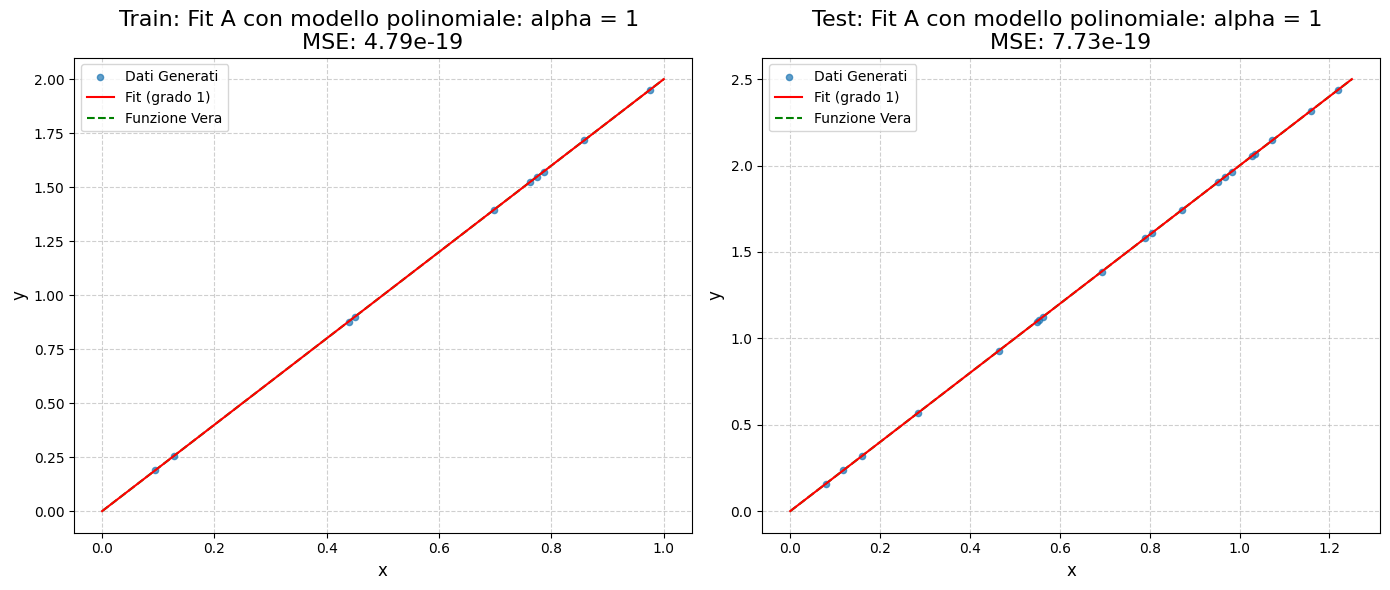

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 3  ---
Pesi veri: [0 2]
Pesi di Best Fit: [ 2.52949914e-08  1.99999975e+00  5.46087683e-07 -3.29422072e-07]
Errore Quadratico Medio (Train): 5.03e-17
Errore Quadratico Medio (Test):  8.36e-17
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_3_ntrain10_ntest20_mean1p1_var0p4_xm0_xM1.png


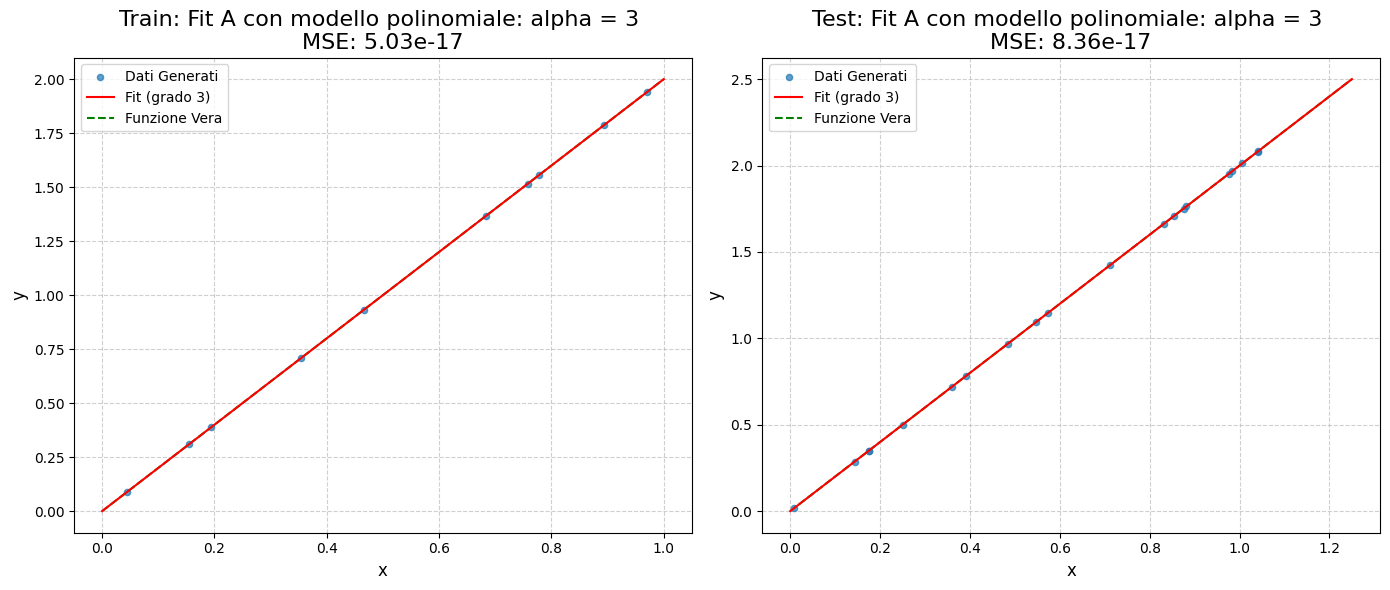

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 10  ---
Pesi veri: [0 2]
Pesi di Best Fit: [ 1.52064901e-04  1.99760314e+00  1.33049449e-02 -3.24997910e-02
  3.08755627e-02  4.06950750e-03 -1.63740925e-02 -8.10641898e-03
  7.36225138e-03  1.00895112e-02 -6.39784037e-03]
Errore Quadratico Medio (Train): 2.08e-13
Errore Quadratico Medio (Test):  1.86e-08
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_10_ntrain10_ntest20_mean1p1_var0p2_xm0_xM1.png


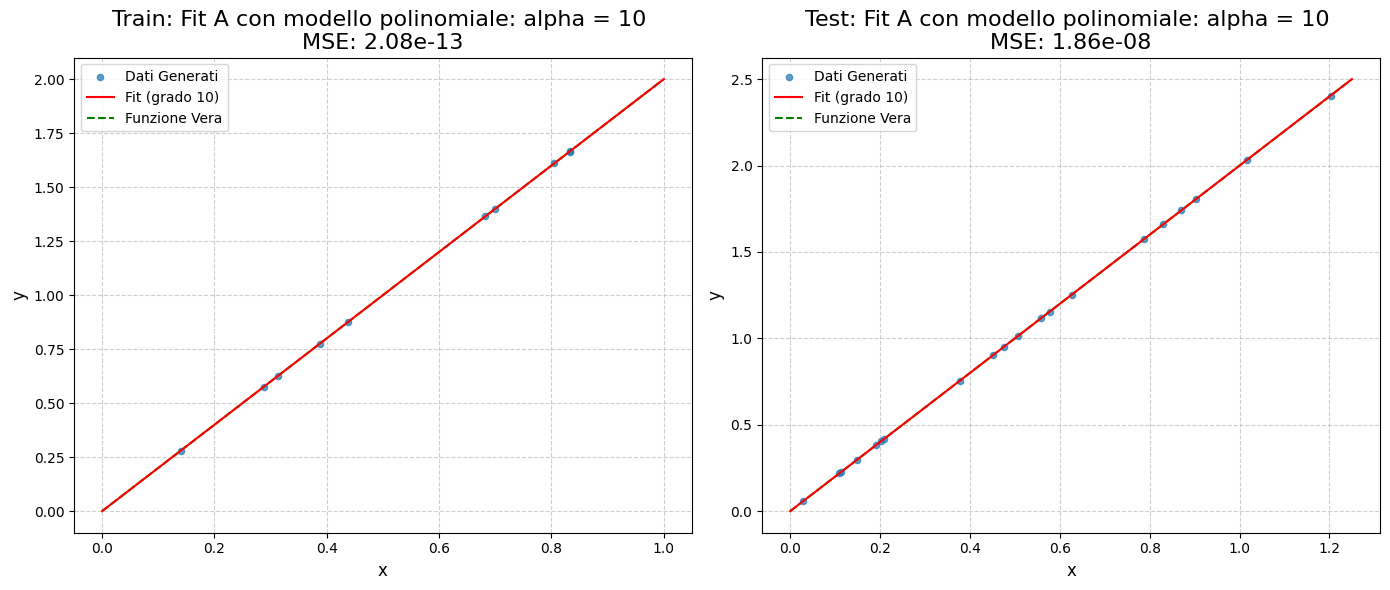

In [ ]:
theta_a = np.array([0, 2])
theta_b = np.array([0, 2, 0, 0, 0, -10, 0, 0, 0, 0, 15])

# Experiment 1
generator_train = SyntheticDataGenerator(P=10, x_m=0, x_M=1, mu=0, sigma=0, seed=42)
generator_test = SyntheticDataGenerator(P=20, x_m=0, x_M=1.25, mu=0, sigma=0, seed=42)

#  Modello A
alphas_model = [1, 3, 10]

for alpha in alphas_model:
  experiment = Experiment(name=f"Fit A con modello polinomiale: alpha = {alpha} ",
                          generator=generator_train,
                          generator_test=generator_test,
                          model=PolynomialRegression(alpha=alpha),
                          true_theta=theta_a
                          )
  experiment.run()
  experiment.plot_results()

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 1  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [ 0.46830068 -0.02951346]
Errore Quadratico Medio (Train): 6.90e-02
Errore Quadratico Medio (Test):  3.40e+02
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_1_ntrain10_ntest20_mean0p5_var0p1_xm0_xM1.png


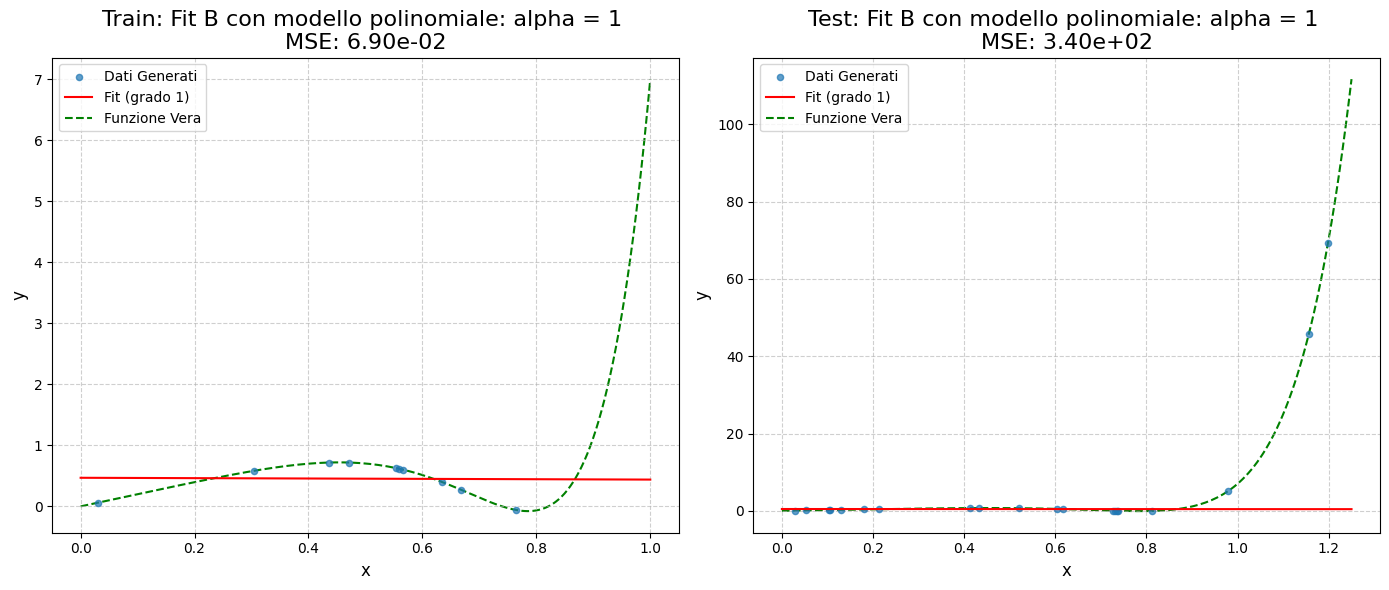

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 3  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [-0.09834251  3.64863349 -4.16622571 -0.44747723]
Errore Quadratico Medio (Train): 5.60e-03
Errore Quadratico Medio (Test):  1.13e+03
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_3_ntrain10_ntest20_mean0p3_var0p1_xm0_xM1.png


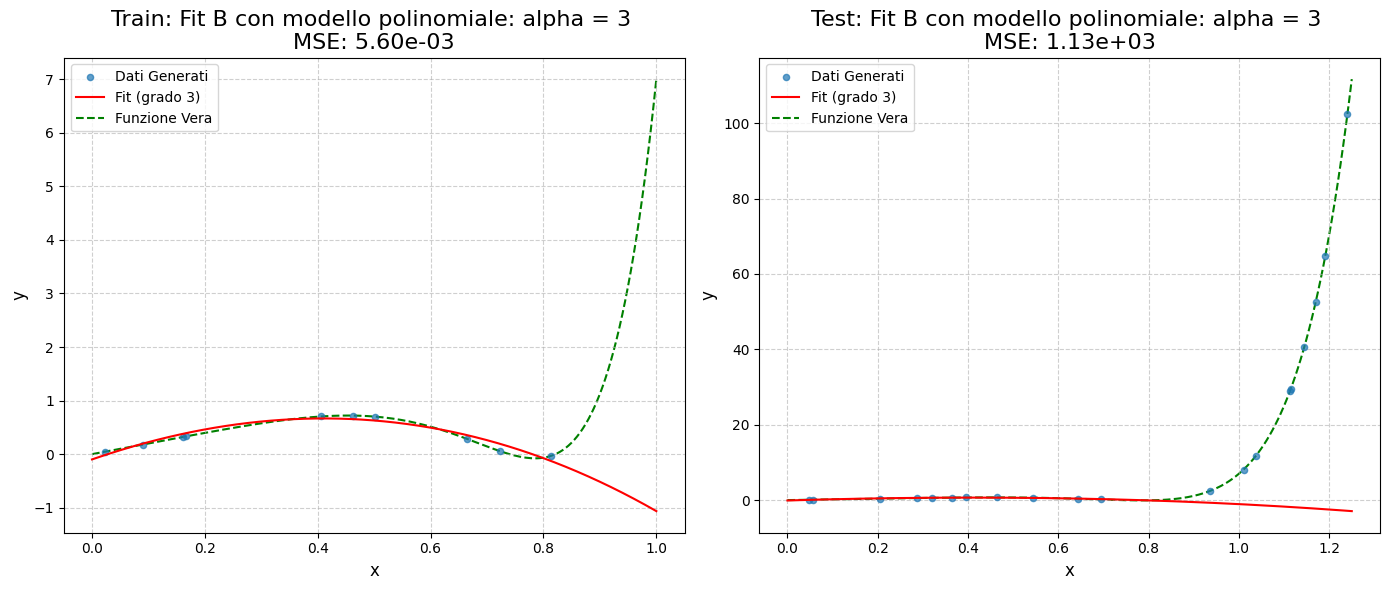

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 10  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [ 8.02708374e-03  1.85775980e+00  7.10607288e-01 -8.56086536e-01
 -2.37367398e+00 -3.25974178e+00 -3.51250691e+00 -2.73834206e+00
 -2.06005244e-01  4.77193052e+00  1.25970346e+01]
Errore Quadratico Medio (Train): 2.98e-10
Errore Quadratico Medio (Test):  5.27e-04
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_10_ntrain10_ntest20_mean0p9_var1p5_xm0_xM1.png


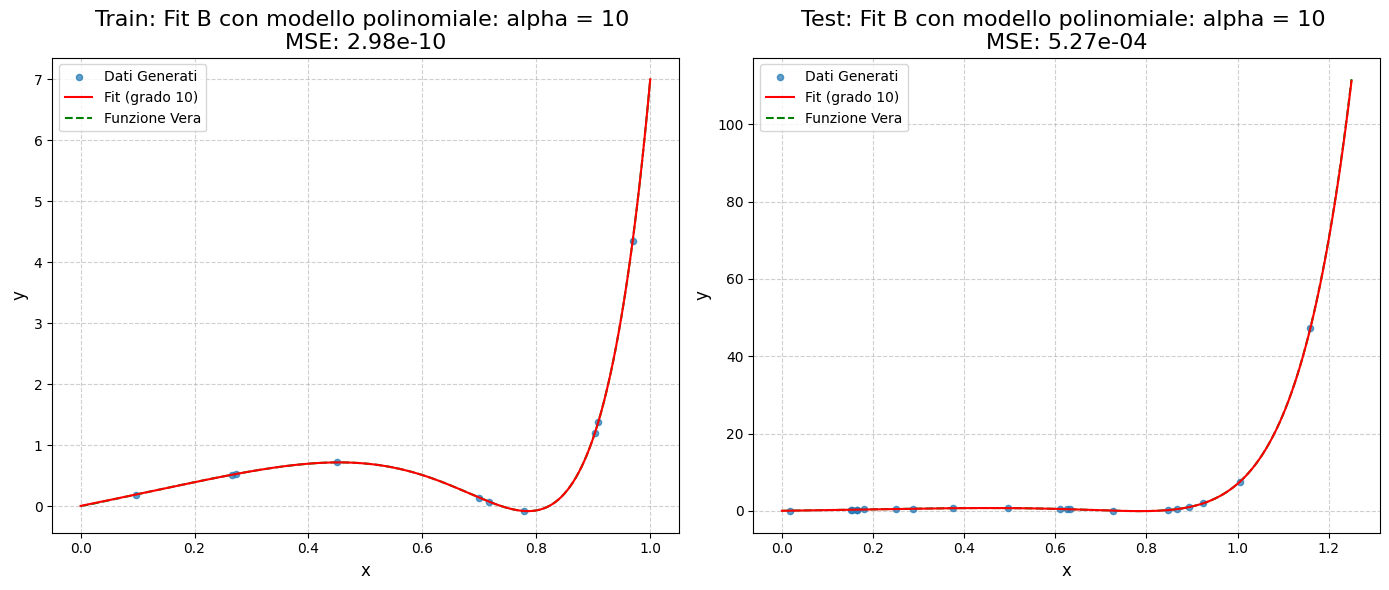

In [ ]:
#  Modello B
alphas_model = [1, 3, 10]

for alpha in alphas_model:
  experiment = Experiment(name=f"Fit B con modello polinomiale: alpha = {alpha} ",
                          generator=generator_train,
                          generator_test=generator_test,
                          model=PolynomialRegression(alpha=alpha),
                          true_theta=theta_b
                          )
  experiment.run()
  experiment.plot_results()

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 1  ---
Pesi veri: [0 2]
Pesi di Best Fit: [-0.05130027  2.07662959]
Errore Quadratico Medio (Train): 9.59e-01
Errore Quadratico Medio (Test):  6.19e-01
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_1_ntrain100_ntest20_mean1p0_var1p3_xm0_xM1.png


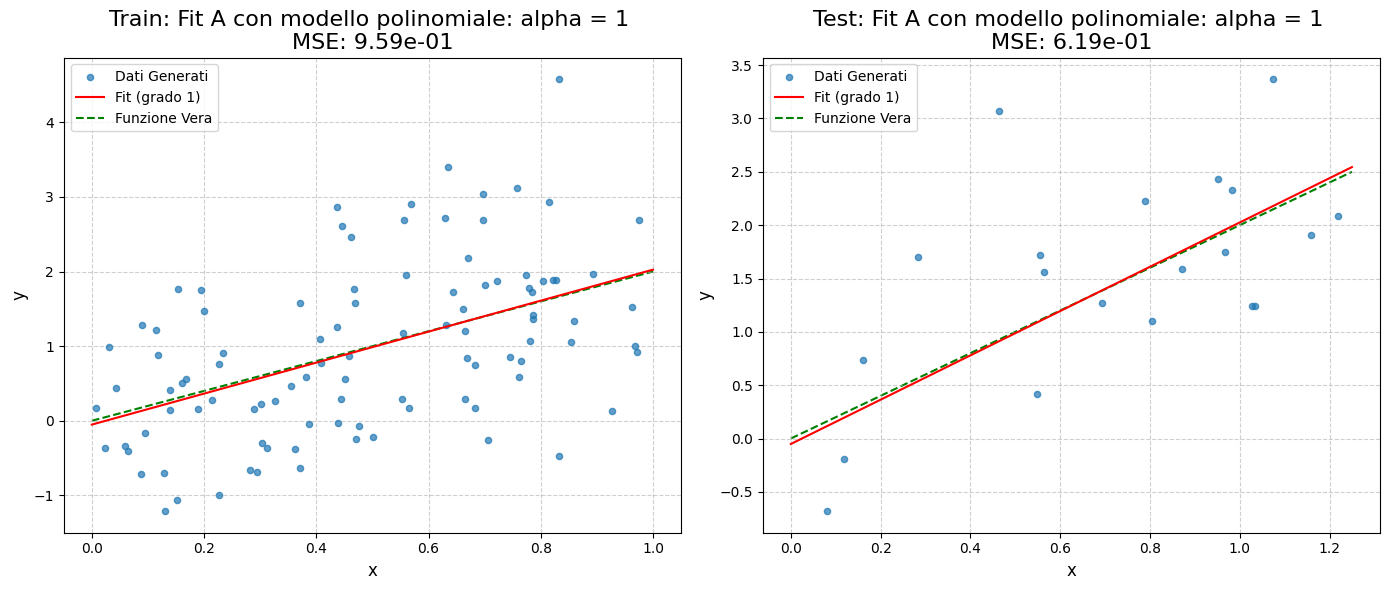

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 3  ---
Pesi veri: [0 2]
Pesi di Best Fit: [-0.28827569  4.64265803 -3.17312243  0.50882833]
Errore Quadratico Medio (Train): 1.04e+00
Errore Quadratico Medio (Test):  6.41e-01
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_3_ntrain100_ntest20_mean1p0_var1p4_xm0_xM1.png


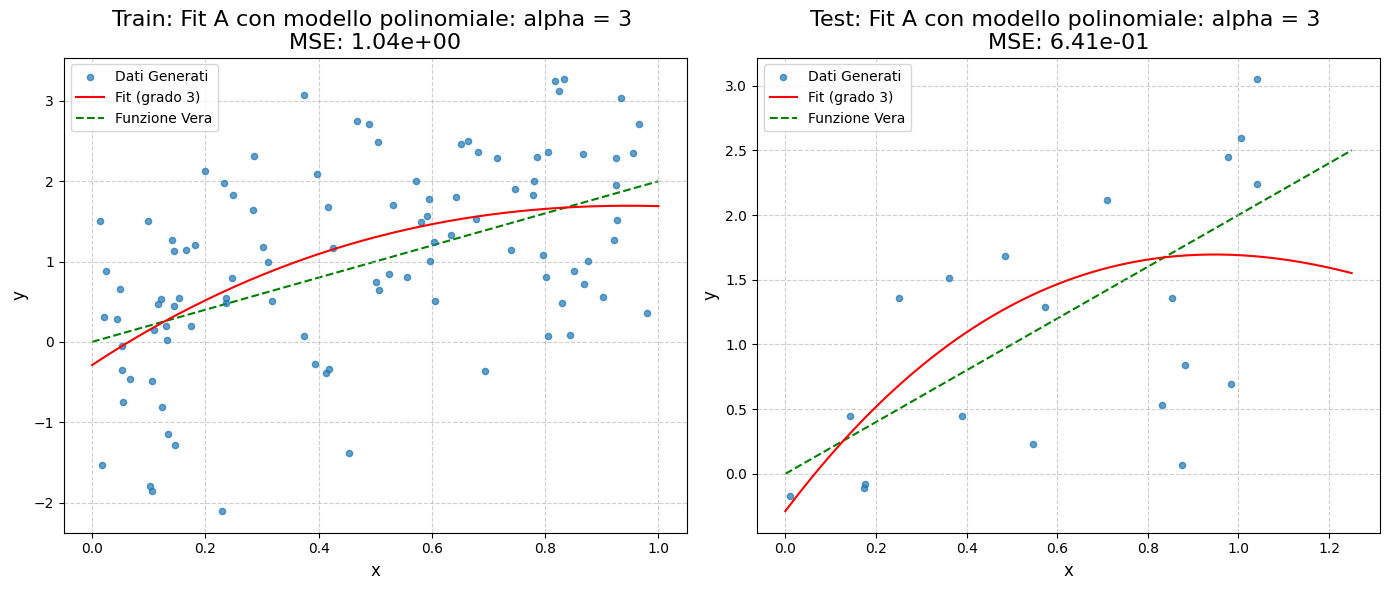

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 10  ---
Pesi veri: [0 2]
Pesi di Best Fit: [-1.74310218e+00  6.97713150e+01 -7.48479226e+02  3.56279055e+03
 -7.81535270e+03  5.75572034e+03  5.01481766e+03 -7.51015583e+03
 -4.55249655e+03  1.01615324e+04 -3.93388872e+03]
Errore Quadratico Medio (Train): 9.10e-01
Errore Quadratico Medio (Test):  1.45e+03
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_10_ntrain100_ntest20_mean0p9_var1p3_xm0_xM1.png


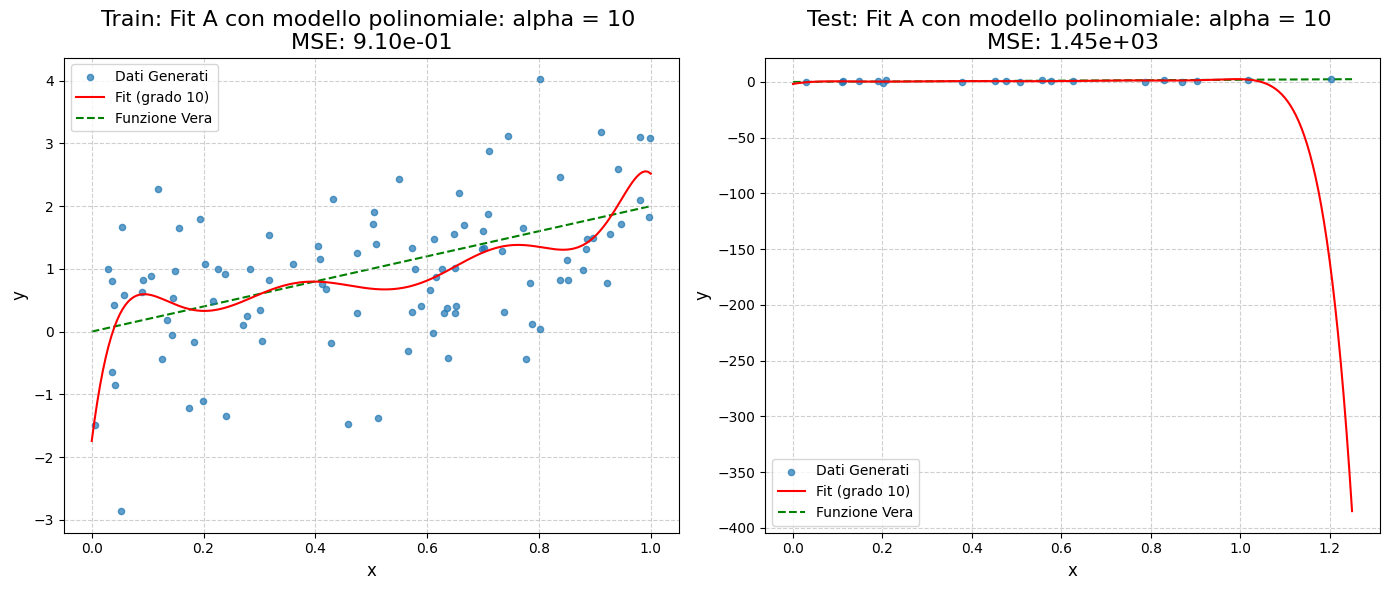

In [ ]:
# Experiment 2
generator_train = SyntheticDataGenerator(P=100, x_m=0, x_M=1, mu=0, sigma=1, seed=42)
generator_test = SyntheticDataGenerator(P=20, x_m=0, x_M=1.25, mu=0, sigma=1, seed=42)

#  Modello A
alphas_model = [1, 3, 10]

for alpha in alphas_model:
  experiment = Experiment(name=f"Fit A con modello polinomiale: alpha = {alpha} ",
                          generator=generator_train,
                          generator_test=generator_test,
                          model=PolynomialRegression(alpha=alpha),
                          true_theta=theta_a
                          )
  experiment.run()
  experiment.plot_results()

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 1  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [0.04169342 1.34627553]
Errore Quadratico Medio (Train): 2.05e+00
Errore Quadratico Medio (Test):  3.28e+02
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_1_ntrain100_ntest20_mean0p7_var2p2_xm0_xM1.png


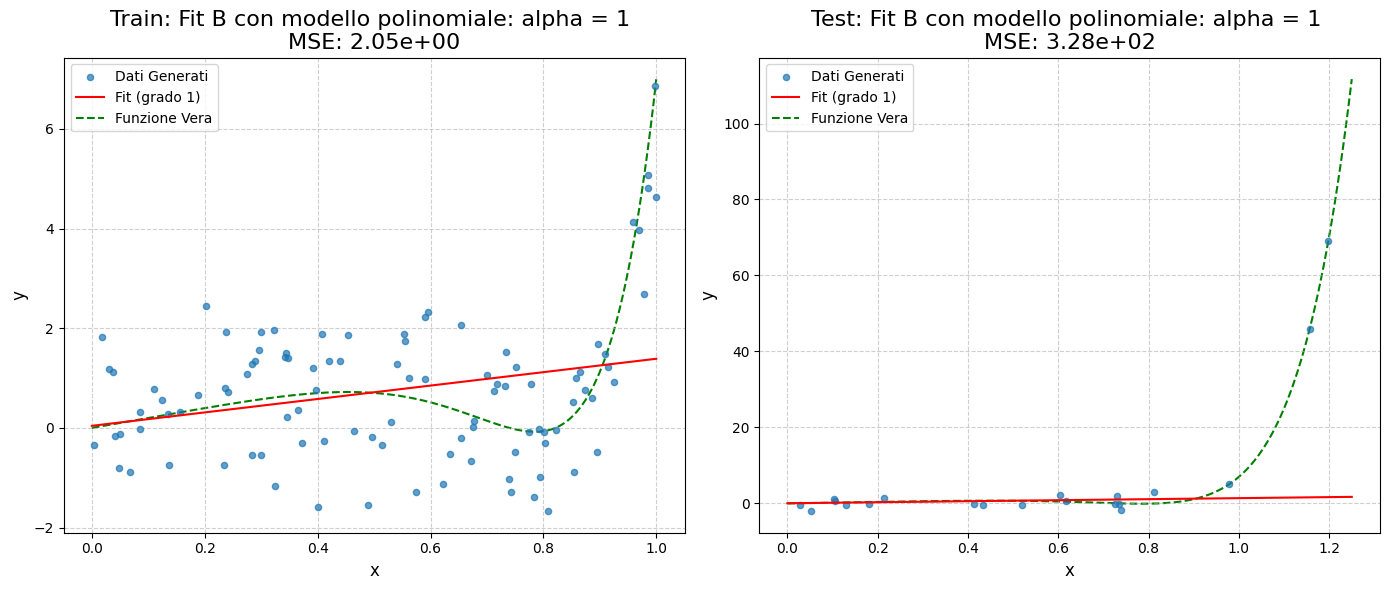

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 3  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [ -0.99563054  17.66746237 -49.68488622  37.54988397]
Errore Quadratico Medio (Train): 1.43e+00
Errore Quadratico Medio (Test):  6.76e+02
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_3_ntrain100_ntest20_mean0p7_var2p5_xm0_xM1.png


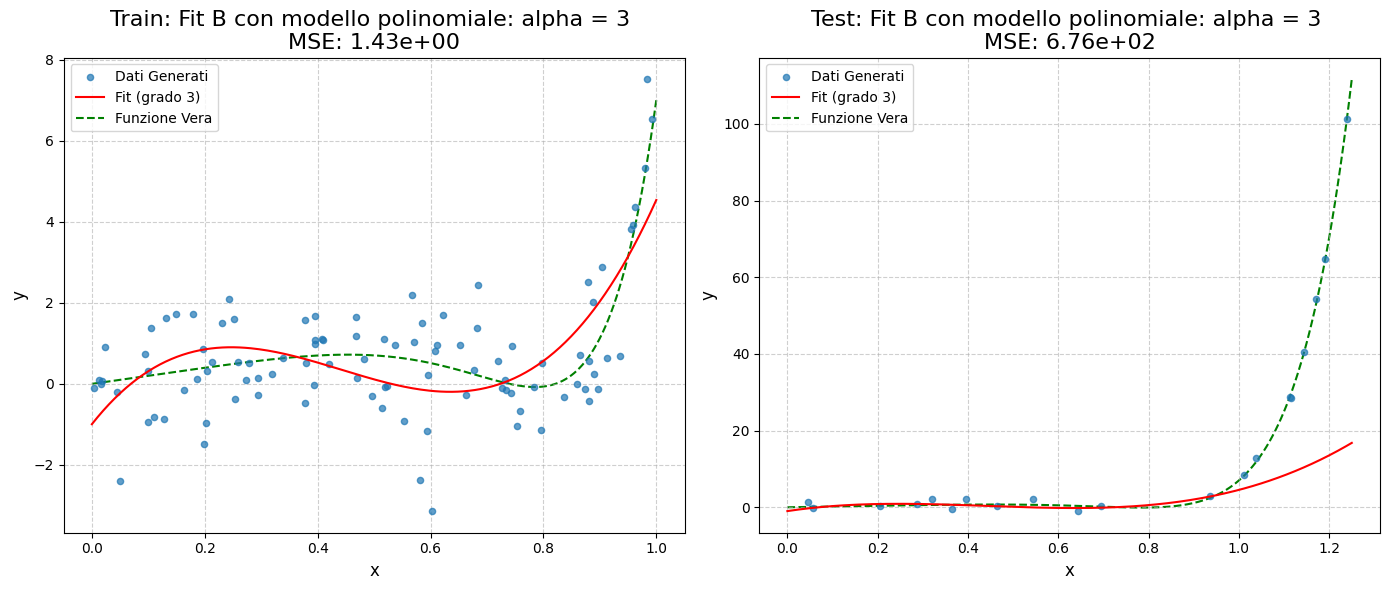

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 10  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [ 5.50133964e-02  2.45696835e+01 -4.77629806e+02  3.14373004e+03
 -9.00611147e+03  1.11972734e+04 -2.27392346e+03 -6.40443662e+03
  1.98432894e+03  3.99558025e+03 -2.17774396e+03]
Errore Quadratico Medio (Train): 9.74e-01
Errore Quadratico Medio (Test):  4.04e+02
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_10_ntrain100_ntest20_mean0p8_var2p2_xm0_xM1.png


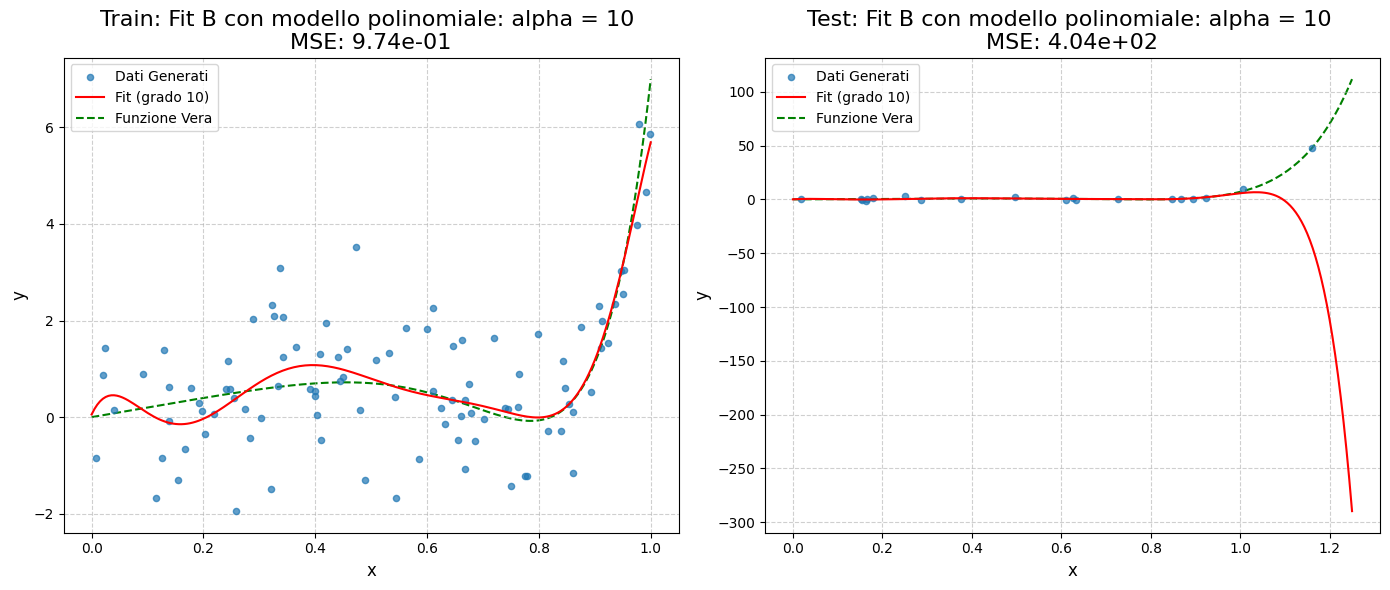

In [ ]:
#  Modello B
alphas_model = [1, 3, 10]

for alpha in alphas_model:
  experiment = Experiment(name=f"Fit B con modello polinomiale: alpha = {alpha} ",
                          generator=generator_train,
                          generator_test=generator_test,
                          model=PolynomialRegression(alpha=alpha),
                          true_theta=theta_b
                          )
  experiment.run()
  experiment.plot_results()

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 1  ---
Pesi veri: [0 2]
Pesi di Best Fit: [0.01798678 1.99207399]
Errore Quadratico Medio (Train): 1.00e+00
Errore Quadratico Medio (Test):  9.60e-01
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_1_ntrain10000_ntest100_mean1p0_var1p3_xm0_xM1.png


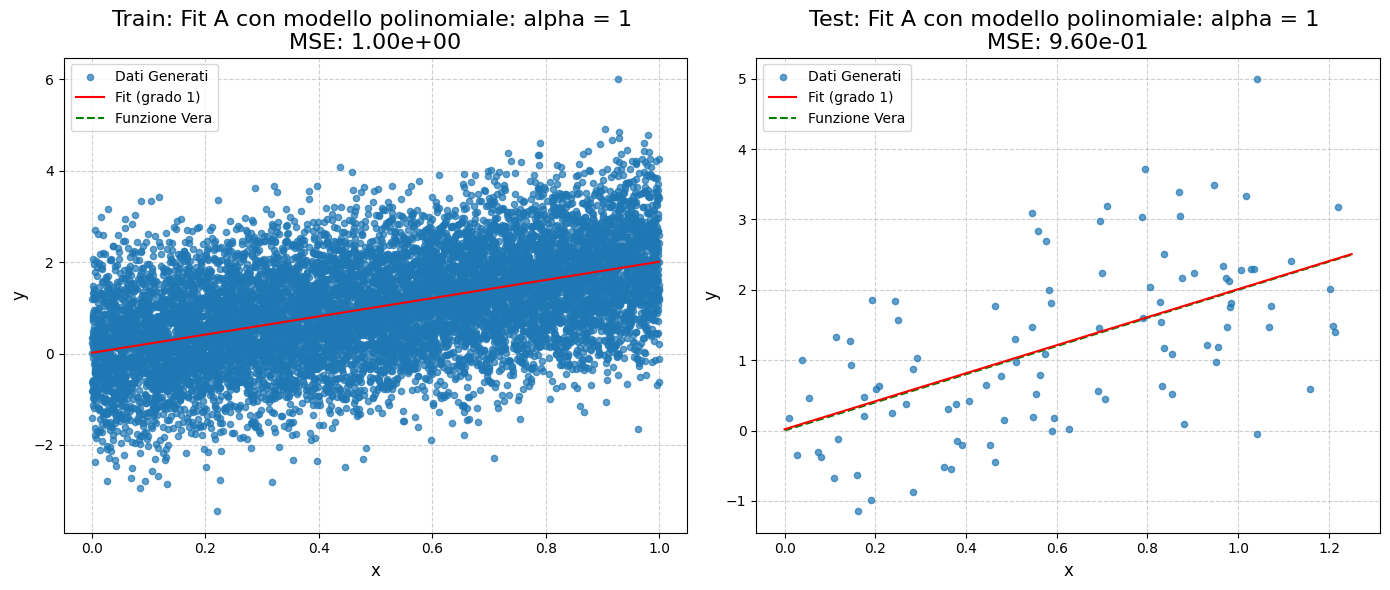

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 3  ---
Pesi veri: [0 2]
Pesi di Best Fit: [-0.01925432  1.94073422  0.4451236  -0.42052332]
Errore Quadratico Medio (Train): 1.01e+00
Errore Quadratico Medio (Test):  1.07e+00
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_3_ntrain10000_ntest100_mean1p0_var1p3_xm0_xM1.png


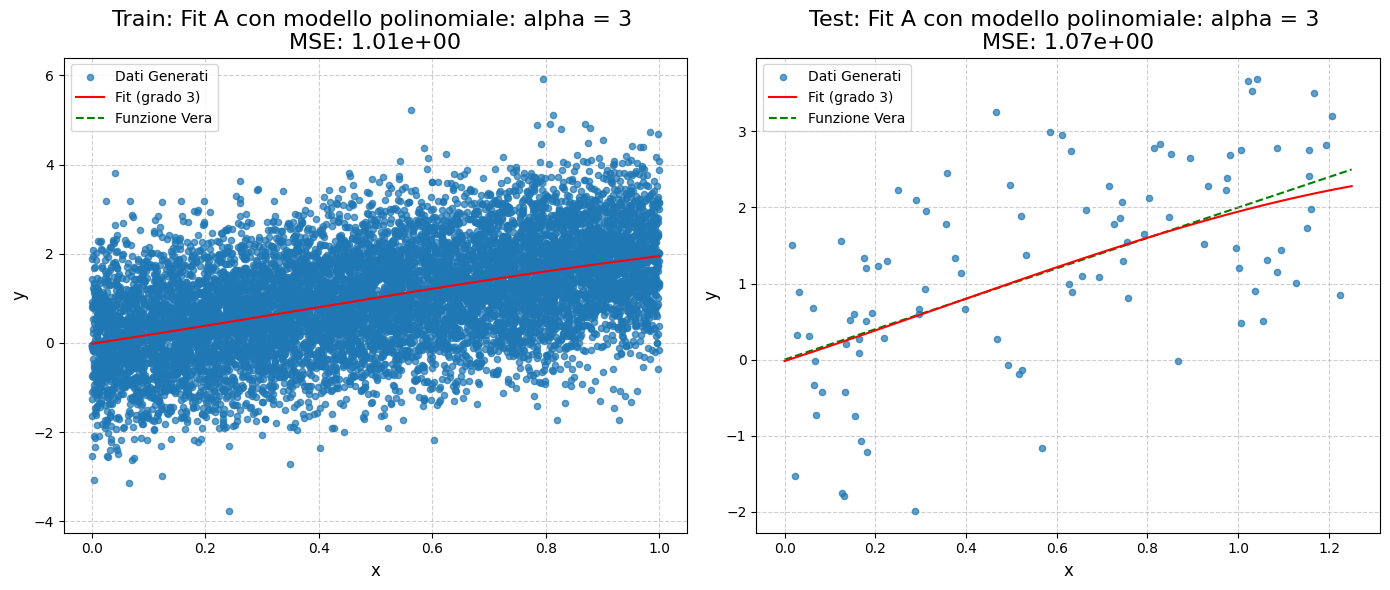

--- Esecuzione Esperimento: Fit A con modello polinomiale: alpha = 10  ---
Pesi veri: [0 2]
Pesi di Best Fit: [-2.78295752e-02  1.58046708e-01  4.96448072e+01 -4.21447800e+02
  1.69484348e+03 -3.53338326e+03  3.50542822e+03 -3.92036495e+02
 -2.43847578e+03  2.10224867e+03 -5.65054857e+02]
Errore Quadratico Medio (Train): 1.01e+00
Errore Quadratico Medio (Test):  2.02e+01
------------------------------------------

Salvataggio della figura in: fit_a_con_modello_polinomiale_alpha_10_ntrain10000_ntest100_mean1p0_var1p3_xm0_xM1.png


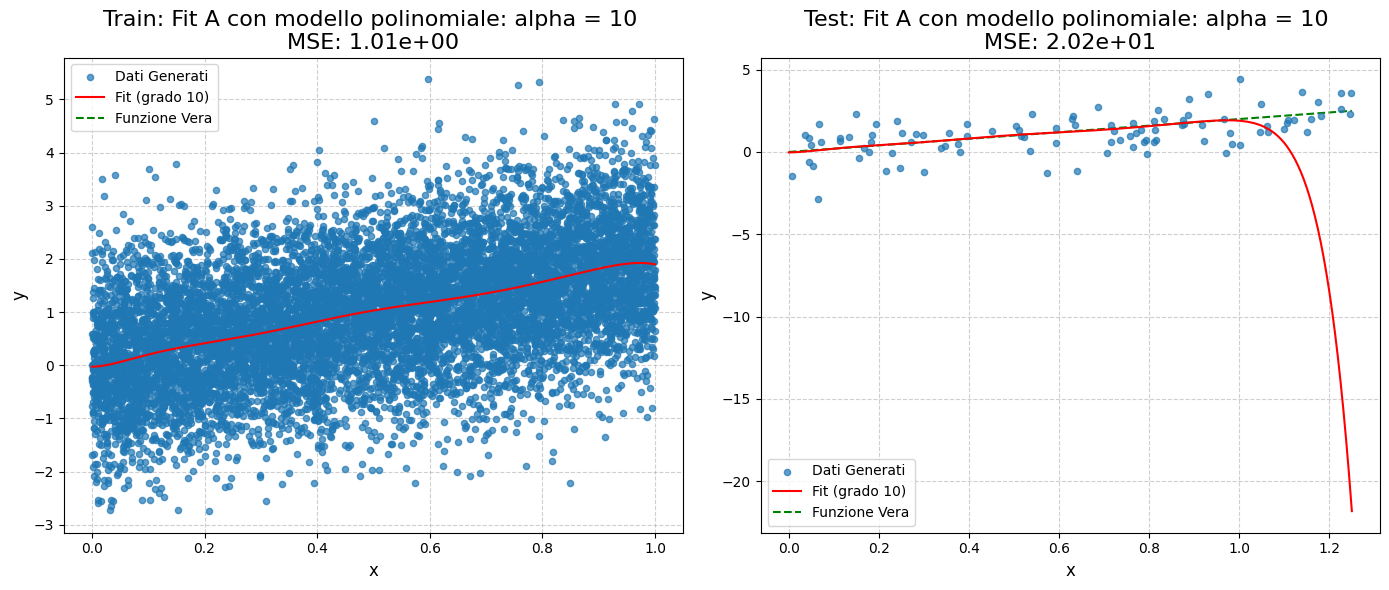

In [ ]:
# Experiment 3
generator_train = SyntheticDataGenerator(P=10000, x_m=0, x_M=1, mu=0, sigma=1, seed=42)
generator_test = SyntheticDataGenerator(P=100, x_m=0, x_M=1.25, mu=0, sigma=1, seed=42)

#  Modello A
alphas_model = [1, 3, 10]

for alpha in alphas_model:
  experiment = Experiment(name=f"Fit A con modello polinomiale: alpha = {alpha} ",
                          generator=generator_train,
                          generator_test=generator_test,
                          model=PolynomialRegression(alpha=alpha),
                          true_theta=theta_a
                          )
  experiment.run()
  experiment.plot_results()

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 1  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [-0.13287526  1.62555775]
Errore Quadratico Medio (Train): 1.94e+00
Errore Quadratico Medio (Test):  6.58e+02
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_1_ntrain10000_ntest100_mean0p7_var2p2_xm0_xM1.png


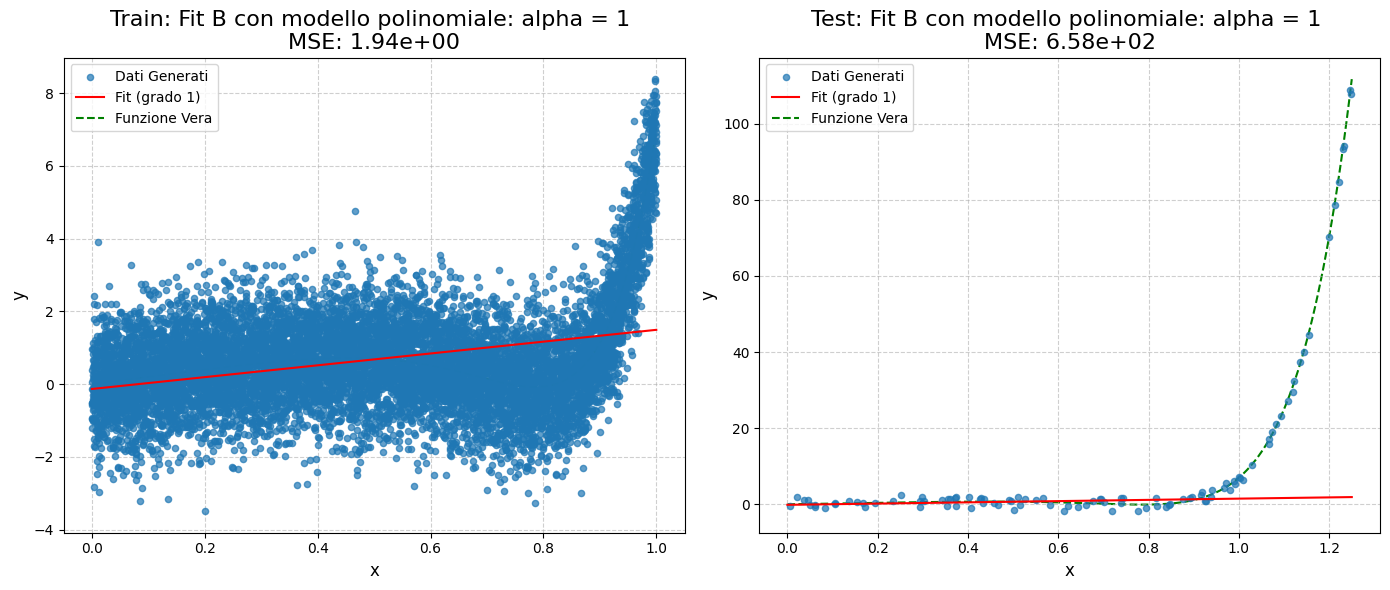

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 3  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [ -0.89247802  16.3997805  -45.41598192  34.08996947]
Errore Quadratico Medio (Train): 1.36e+00
Errore Quadratico Medio (Test):  3.60e+02
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_3_ntrain10000_ntest100_mean0p7_var2p2_xm0_xM1.png


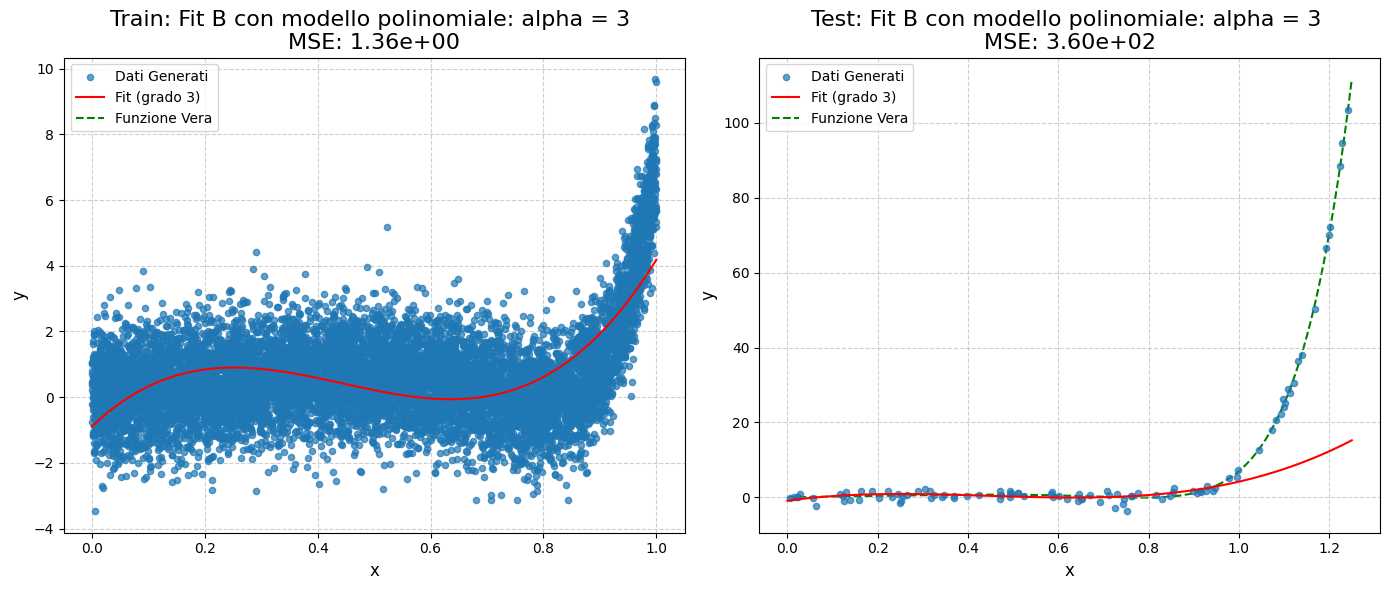

--- Esecuzione Esperimento: Fit B con modello polinomiale: alpha = 10  ---
Pesi veri: [  0   2   0   0   0 -10   0   0   0   0  15]
Pesi di Best Fit: [-6.28234239e-02  6.67593785e+00 -7.38179045e+01  5.08270058e+02
 -1.84980946e+03  3.78275543e+03 -4.35636264e+03  2.51320985e+03
 -3.70442027e+02 -2.47386500e+02  9.40651865e+01]
Errore Quadratico Medio (Train): 1.01e+00
Errore Quadratico Medio (Test):  2.30e+00
------------------------------------------

Salvataggio della figura in: fit_b_con_modello_polinomiale_alpha_10_ntrain10000_ntest100_mean0p7_var2p2_xm0_xM1.png


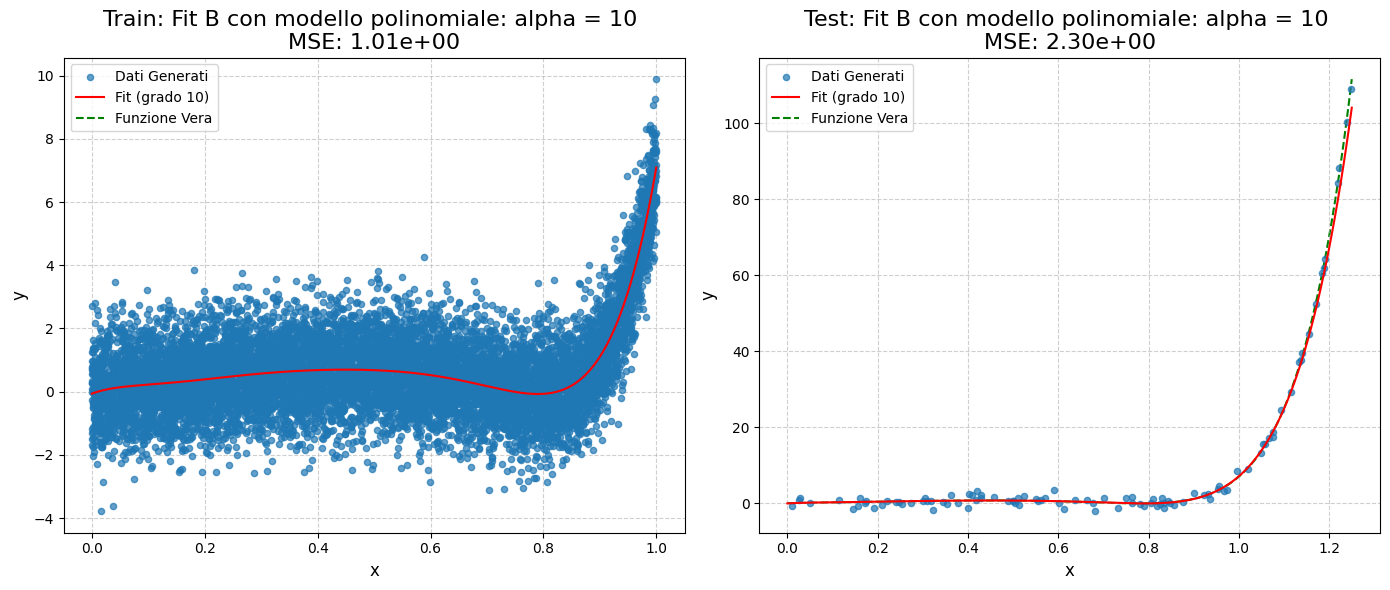

In [ ]:
#  Modello B
alphas_model = [1, 3, 10]

for alpha in alphas_model:
  experiment = Experiment(name=f"Fit B con modello polinomiale: alpha = {alpha} ",
                          generator=generator_train,
                          generator_test=generator_test,
                          model=PolynomialRegression(alpha=alpha),
                          true_theta=theta_b
                          )
  experiment.run()
  experiment.plot_results()